<a href="https://colab.research.google.com/github/Akshayay09/linear-regression-health-costs/blob/main/predict%20health%20costs%20with%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset

--2026-04-03 19:02:37--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 172.67.70.149, 104.26.3.33, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|172.67.70.149|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K   255KB/s    in 0.2s    

2026-04-03 19:02:42 (255 KB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [11]:
# Reload dataset (to avoid KeyError)
dataset = pd.read_csv('insurance.csv')

# Generate dummies for sex
dataset = pd.concat([dataset, pd.get_dummies(dataset['sex'], prefix="sex")], axis=1)
dataset.drop('sex', axis=1, inplace=True)

# Generate dummies for smoker
dataset = pd.concat([dataset, pd.get_dummies(dataset['smoker'], prefix="smoker")], axis=1)
dataset.drop('smoker', axis=1, inplace=True)

# Generate dummies for region
dataset = pd.concat([dataset, pd.get_dummies(dataset['region'], prefix="region")], axis=1)
dataset.drop('region', axis=1, inplace=True)

# Convert everything to float (VERY IMPORTANT)
dataset = dataset.astype('float32')

dataset

,age,bmi,children,expenses,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,27.900000,0.0,16884.919922,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18.0,33.799999,1.0,1725.550049,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28.0,33.000000,3.0,4449.459961,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33.0,22.700001,0.0,21984.470703,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32.0,28.900000,0.0,3866.860107,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50.0,31.000000,3.0,10600.549805,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,18.0,31.900000,0.0,2205.979980,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,18.0,36.900002,0.0,1629.829956,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,21.0,25.799999,0.0,2007.949951,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [12]:
x_columns = dataset.columns.drop('expenses')
x = dataset[x_columns].values
y = dataset['expenses'].values

In [13]:
train_dataset, test_dataset, train_labels, test_labels = train_test_split(x, y, train_size=0.8)

In [14]:
from tensorflow.keras import Input

# 🔥 Ensure correct datatype
train_dataset = train_dataset.astype('float32')
test_dataset = test_dataset.astype('float32')
train_labels = train_labels.astype('float32')
test_labels = test_labels.astype('float32')

# Build model (clean way)
model = Sequential([
    Input(shape=(train_dataset.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

# Compile
model.compile(
    optimizer='adam',
    loss='mean_absolute_error',
    metrics=['mean_absolute_error', 'mean_squared_error']
)

# Early stopping
monitor = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    train_dataset,
    train_labels,
    validation_data=(test_dataset, test_labels),
    epochs=500,
    verbose=1,
    callbacks=[monitor]
)

Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 13394.3428 - mean_absolute_error: 13394.3428 - mean_squared_error: 325156416.0000 - val_loss: 12697.1973 - val_mean_absolute_error: 12697.1973 - val_mean_squared_error: 310475520.0000
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13340.5635 - mean_absolute_error: 13340.5635 - mean_squared_error: 323604160.0000 - val_loss: 12608.2500 - val_mean_absolute_error: 12608.2500 - val_mean_squared_error: 308041056.0000
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13175.1670 - mean_absolute_error: 13175.1670 - mean_squared_error: 318926336.0000 - val_loss: 12343.2871 - val_mean_absolute_error: 12343.2871 - val_mean_squared_error: 300868288.0000
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12733.7207 - mean_absolute_error: 12733.7207 - mean_squared_error: 306605408.0000 - val_loss: 11692.8428 - val_mean_absolute_error: 11692.8428 - val_mean_squared_error: 283895520.0000
Epoch 5/500
34/34 ━━━━━━━━━

9/9 - 0s - 6ms/step - loss: 2620.9963 - mean_absolute_error: 2620.9963 - mean_squared_error: 34825004.0000
Testing set Mean Abs Error: 2621.00 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


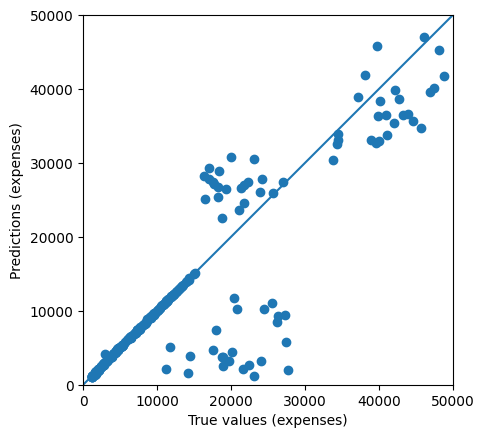

In [15]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
